In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.learning.data import get_data
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

df = get_data()

100%|██████████| 11/11 [00:44<00:00,  4.01s/it]


In [17]:
features = df.drop(columns=['id', 'flag'], errors='ignore')
correlations = features.corrwith(df['flag'])
top_correlations = correlations.abs().sort_values(ascending=False)
res = correlations.loc[top_correlations.index].head(10)
display(pd.DataFrame(res))

,0
is_zero_loans3060_mean,-0.070496
is_zero_loans90_mean,-0.068483
is_zero_loans6090_mean,-0.067229
is_zero_loans530_mean,-0.057111
enc_paym_1_last,0.053644
enc_paym_2_last,0.053328
enc_paym_3_last,0.050991
is_zero_loans6090_min,-0.050860
is_zero_loans3060_min,-0.049770
is_zero_loans90_min,-0.049350


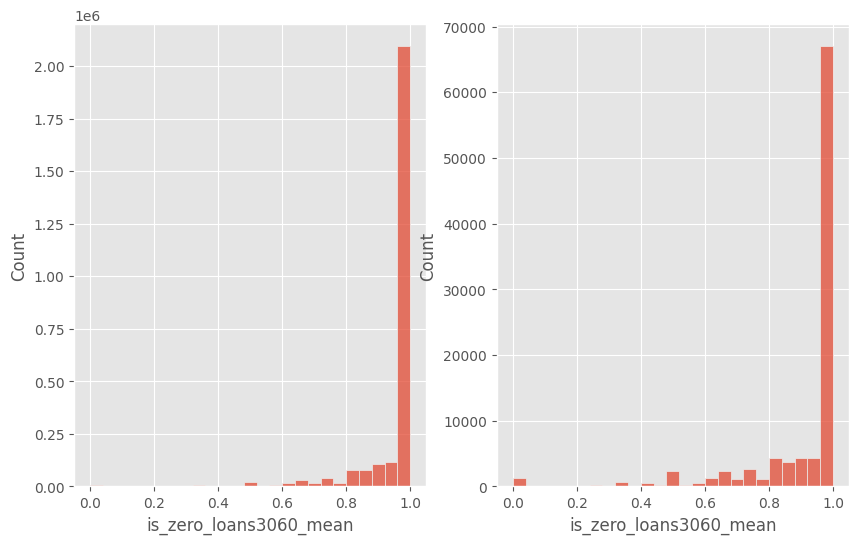

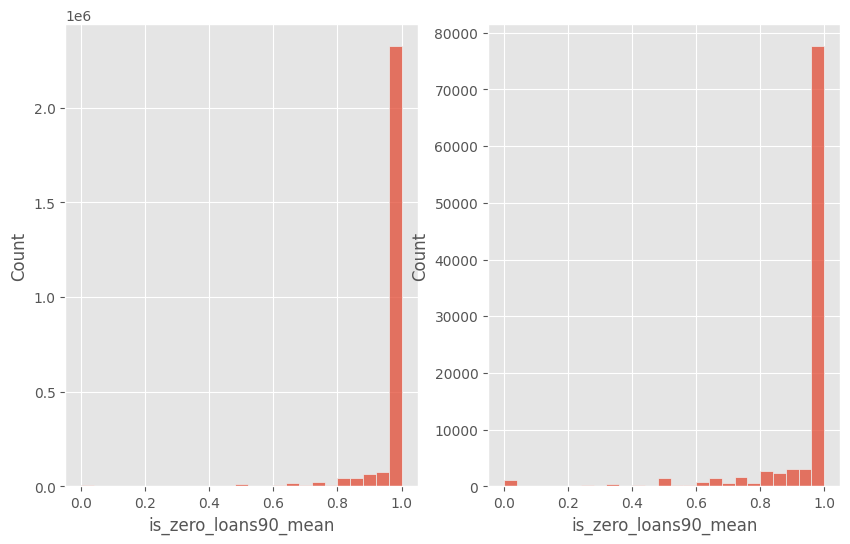

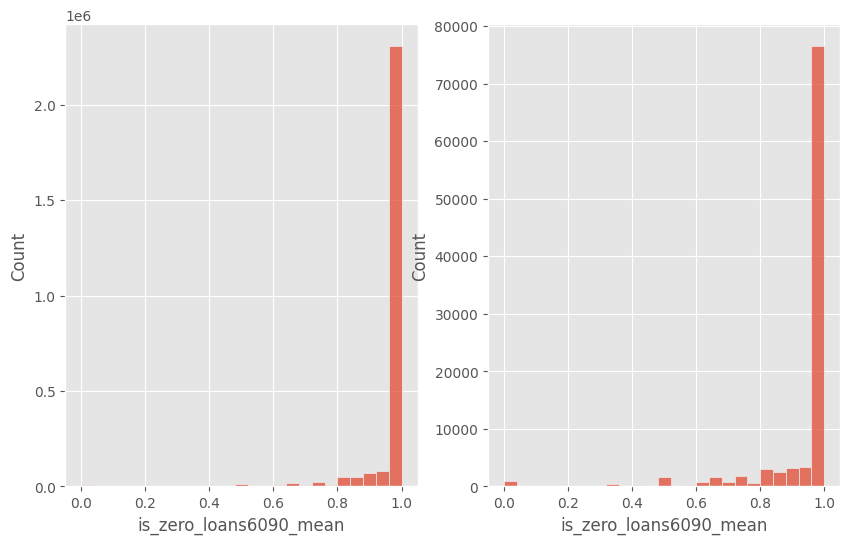

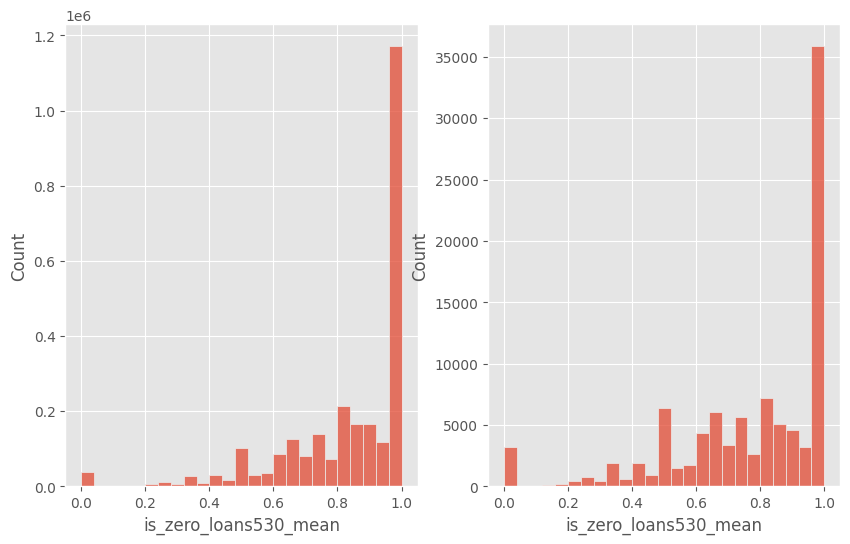

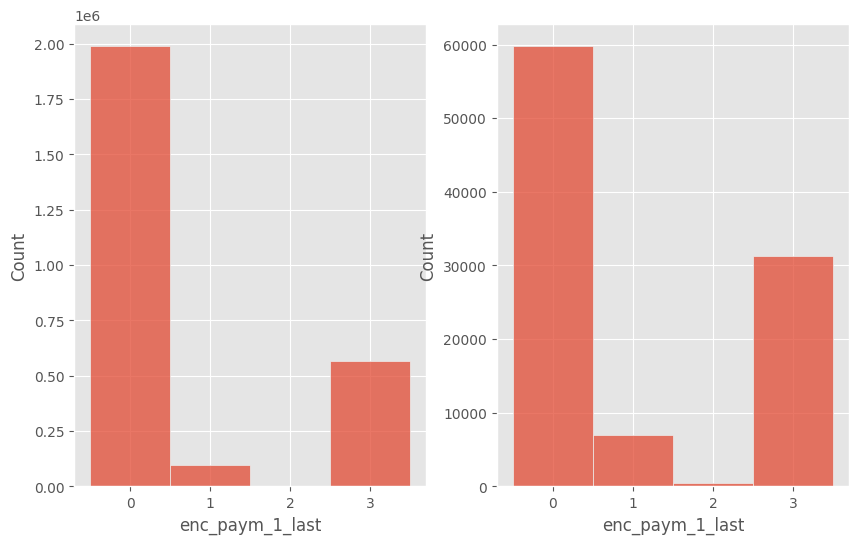

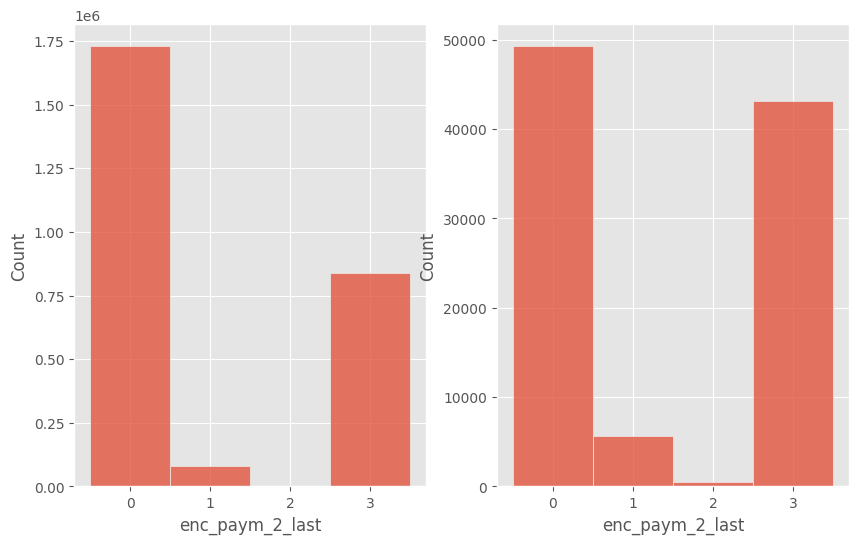

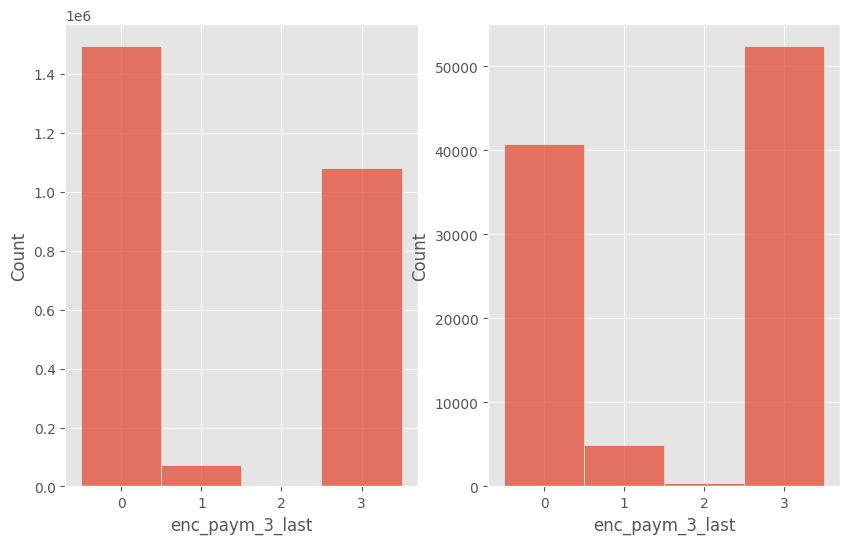

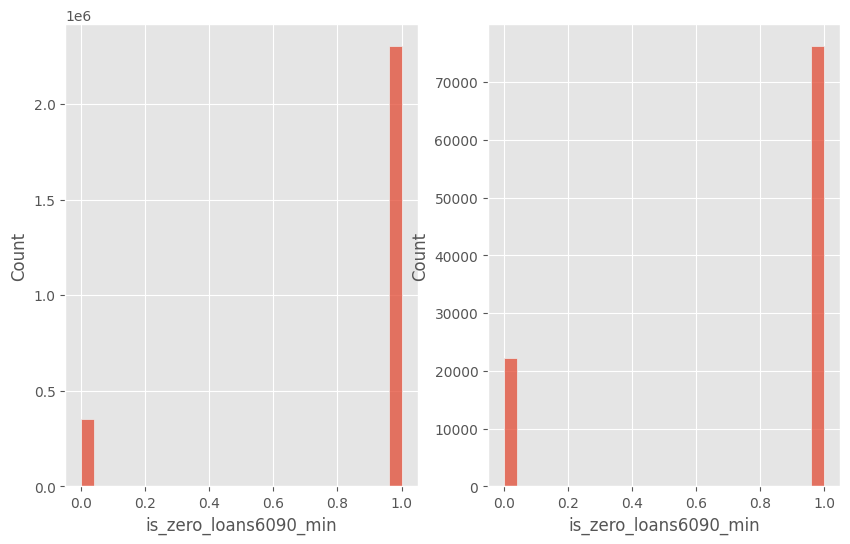

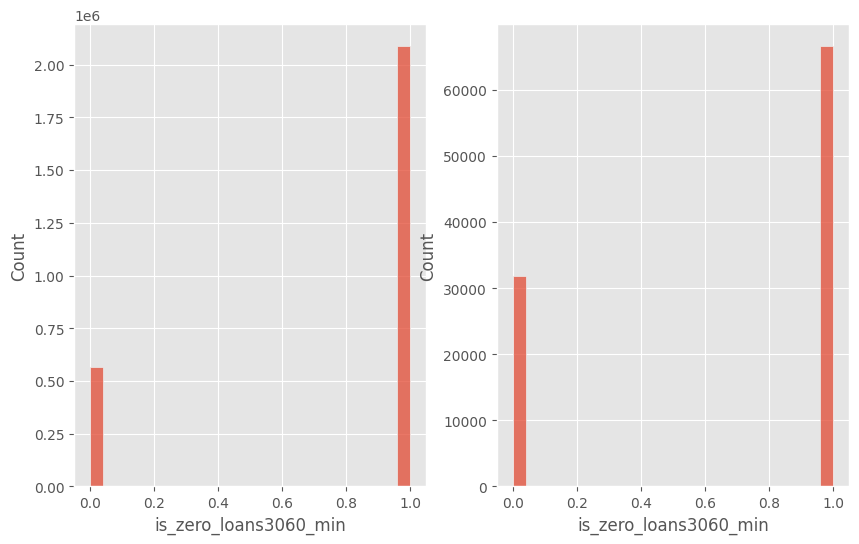

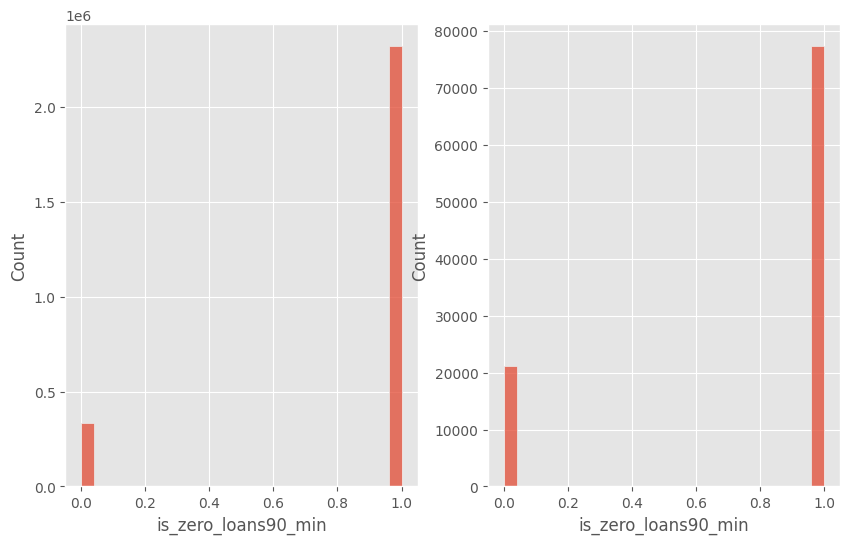

In [18]:
for col in res.index:
    data = df.loc[:, ['id', col, 'flag']]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
    sns.histplot(data=data[data['flag'] == 0][col], ax=ax[0], bins=25)
    sns.histplot(data=data[data['flag'] == 1][col], ax=ax[1], bins=25)